In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
fname = "./pywrdrb/drought_metrics/stationary_ensemble_ssi12_drought_events.csv"
df = pd.read_csv(fname, index_col=0)
df['magnitude'] = np.abs(df['magnitude'])
df['severity'] = np.abs(df['severity'])

# Drop any rows with inf in magnitude or severity
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['magnitude', 'severity'])


df['magnitude'] = np.log(df['magnitude'])
df['severity'] = np.log(df['severity'])


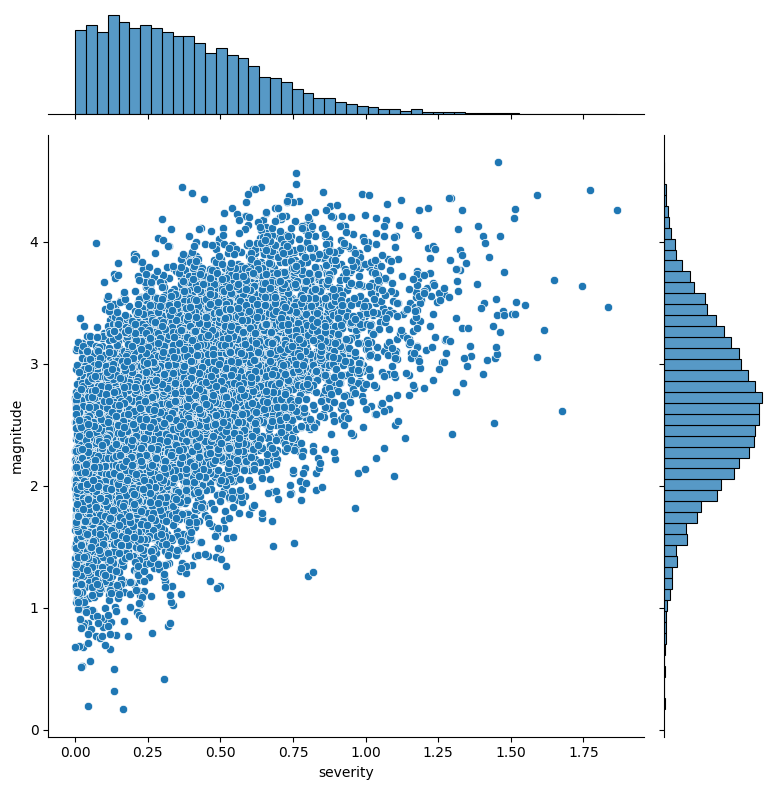

In [2]:
x_col = 'severity'
y_col = 'magnitude'

# Plot joint scatter of x and y
sns.jointplot(data=df, x=x_col, y=y_col, kind="scatter", height=8, marginal_kws=dict(bins=50, fill=True))

## Fitting Marginal Distributions


In [4]:
def select_best_distribution(data, candidates, **fit_kwargs):
   """
   Select the best-fitting distribution based on uniformity of transformed data.
   
   Parameters:
   -----------
   data : array-like
       Data to fit distributions to
   candidates : list of scipy.stats distributions
       List of scipy distribution objects to test
   **fit_kwargs : dict
       Additional arguments passed to distribution fit() method
   
   Returns:
   --------
   tuple : (best_dist, best_params, results_summary)
       - best_dist: scipy distribution object that fits best
       - best_params: fitted parameters for best distribution
       - results_summary: dict with KS test results for all candidates
   """
   from scipy import stats
   
   results = {}
   
   # Fit each candidate and test uniformity
   for dist in candidates:
       try:
           params = dist.fit(data, **fit_kwargs)
           u_transformed = dist.cdf(data, *params)
           ks_stat, ks_pval = stats.kstest(u_transformed, 'uniform')
           
           results[dist.name] = {
               'params': params,
               'ks_stat': ks_stat,
               'ks_pval': ks_pval,
               'dist': dist
           }
       except Exception as e:
           print(f"Failed to fit {dist.name}: {e}")
   
   # Find best distribution (highest p-value)
   best_name = max(results.keys(), key=lambda k: results[k]['ks_pval'])
   best_result = results[best_name]
   
   # Print summary
   print("Distribution uniformity test results:")
   print("-" * 45)
   for name, result in sorted(results.items(), key=lambda x: x[1]['ks_pval'], reverse=True):
       print(f"{name:12} | KS p-val: {result['ks_pval']:.4f} | KS stat: {result['ks_stat']:.4f}")
   print(f"\nBest: {best_name}")
   
   return best_result['dist'], best_result['params'], results

extreme_candidates = [
   # Extreme Value Theory
   stats.genpareto,      # Generalized Pareto - gold standard for extremes
   stats.genextreme,     # Generalized Extreme Value (GEV)
   stats.pareto,         # Pareto (power law tail)
   
   # Heavy-tailed distributions
   stats.burr12,         # Burr XII - very flexible, 3 parameters
   stats.burr,           # Burr III
   stats.invweibull,     # Inverse Weibull
   stats.powerlognorm,   # Power log-normal
   
   # Flexible multi-parameter families
   stats.invgamma,       # Inverse gamma
   stats.invgauss,       # Inverse Gaussian
   stats.gengamma,       # Generalized gamma (4 parameters)
   stats.genlogistic,    # Generalized logistic
   
   # Alternative heavy-tailed options
   stats.exponweib,      # Exponentiated Weibull
   stats.exponpow,       # Exponential power
   stats.genexpon,
   stats.lognorm,        # Log-normal (for comparison)
   stats.pearson3,       # Pearson III
   stats.skewnorm,       # Skew normal
   
   # Current best performers (for comparison)
   stats.weibull_min,    # Current severity best
   stats.gamma,          # Fallback option
]
# Test distributions for severity data (remember: using shifted severity - 1)
severity_candidates = [
   stats.expon,      # Exponential (our current choice)
   stats.genexpon,
   stats.pearson3,
   stats.gamma,      # Gamma (flexible alternative)
   stats.invgamma,    # Inverse gamma
   stats.weibull_min, # Weibull
   stats.genpareto,     # generalized Pareto (single-sided, heavy tail)
   stats.rayleigh,   # Rayleigh (special case of Weibull)
   stats.lognorm,
   stats.chi2        # Chi-squared
]

print("SEVERITY DISTRIBUTION SELECTION:")
print("="*50)
best_sev_dist, best_sev_params, sev_summary = select_best_distribution(
   df['severity'], extreme_candidates
)

print("\n" + "="*50)
print("MAGNITUDE DISTRIBUTION SELECTION:")
print("="*50)

magnitude_candidates = [
   stats.gamma,      # Current choice
   stats.weibull_min, # Often better for skewed data
   stats.lognorm,    # Log-normal
   stats.genpareto,  # Generalized Pareto
   stats.invgamma,   # Inverse gamma
   stats.chi2        # Chi-squared
]

best_mag_dist, best_mag_params, mag_summary = select_best_distribution(
   df['magnitude'], extreme_candidates
)

print(f"\nFINAL SELECTIONS:")
print(f"Severity: {best_sev_dist.name} with params {best_sev_params}")
print(f"Magnitude: {best_mag_dist.name} with params {best_mag_params}")

SEVERITY DISTRIBUTION SELECTION:
Distribution uniformity test results:
---------------------------------------------
gengamma     | KS p-val: 0.2132 | KS stat: 0.0101
genexpon     | KS p-val: 0.0770 | KS stat: 0.0121
exponweib    | KS p-val: 0.0735 | KS stat: 0.0122
burr         | KS p-val: 0.0363 | KS stat: 0.0135
exponpow     | KS p-val: 0.0000 | KS stat: 0.0236
weibull_min  | KS p-val: 0.0000 | KS stat: 0.0298
burr12       | KS p-val: 0.0000 | KS stat: 0.0299
skewnorm     | KS p-val: 0.0000 | KS stat: 0.0319
powerlognorm | KS p-val: 0.0000 | KS stat: 0.0351
invgauss     | KS p-val: 0.0000 | KS stat: 0.0382
lognorm      | KS p-val: 0.0000 | KS stat: 0.0386
invgamma     | KS p-val: 0.0000 | KS stat: 0.0387
invweibull   | KS p-val: 0.0000 | KS stat: 0.0390
genextreme   | KS p-val: 0.0000 | KS stat: 0.0390
genlogistic  | KS p-val: 0.0000 | KS stat: 0.0404
pearson3     | KS p-val: 0.0000 | KS stat: 0.0432
gamma        | KS p-val: 0.0000 | KS stat: 0.0433
genpareto    | KS p-val: 0.0000 |

In [5]:
# Transform to uniform using best fitted distributions
u_severity = best_sev_dist.cdf(df['severity'], *best_sev_params)
u_magnitude = best_mag_dist.cdf(df['magnitude'], *best_mag_params)

# Update uniform data matrix for copula
U = np.column_stack([u_severity, u_magnitude])

## Dependence structure analysis


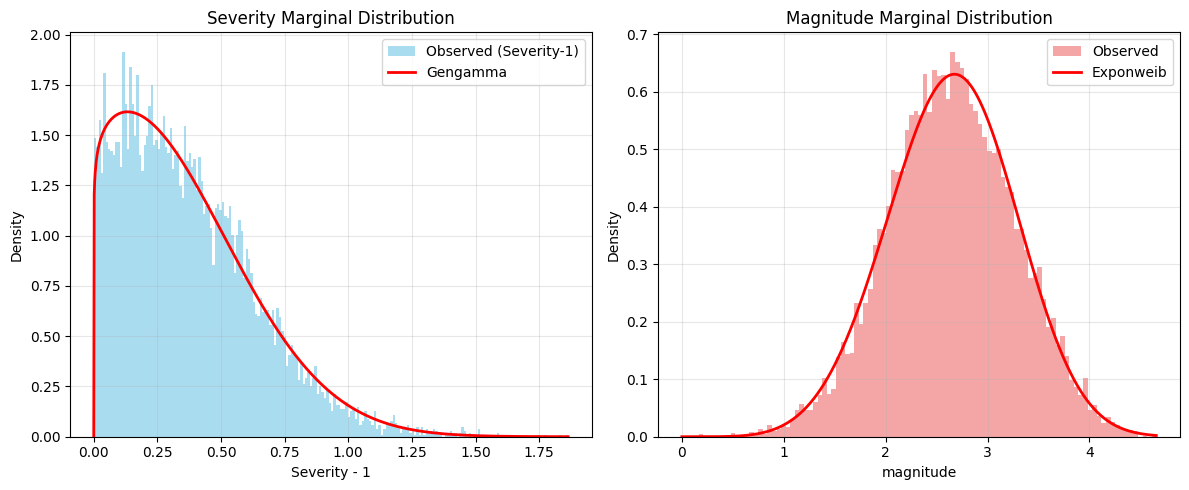

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Severity marginal (using shifted data)
x_sev_shifted = np.linspace(0, df['severity'].max(), 1000)
ax1.hist(df['severity'], bins=200, density=True, alpha=0.7, color='skyblue', label='Observed (Severity-1)')
ax1.plot(x_sev_shifted, best_sev_dist.pdf(x_sev_shifted, *best_sev_params), 'r-', lw=2, label=f'{best_sev_dist.name.title()}')
ax1.set_xlabel('Severity - 1')
ax1.set_ylabel('Density')
ax1.set_title('Severity Marginal Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Magnitude marginal
x_mag = np.linspace(0, df['magnitude'].max(), 1000)
ax2.hist(df['magnitude'], bins=100, density=True, alpha=0.7, color='lightcoral', label='Observed')
ax2.plot(x_mag, best_mag_dist.pdf(x_mag, *best_mag_params), 'r-', lw=2, label=f'{best_mag_dist.name.title()}')
ax2.set_xlabel('magnitude')
ax2.set_ylabel('Density')
ax2.set_title('Magnitude Marginal Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

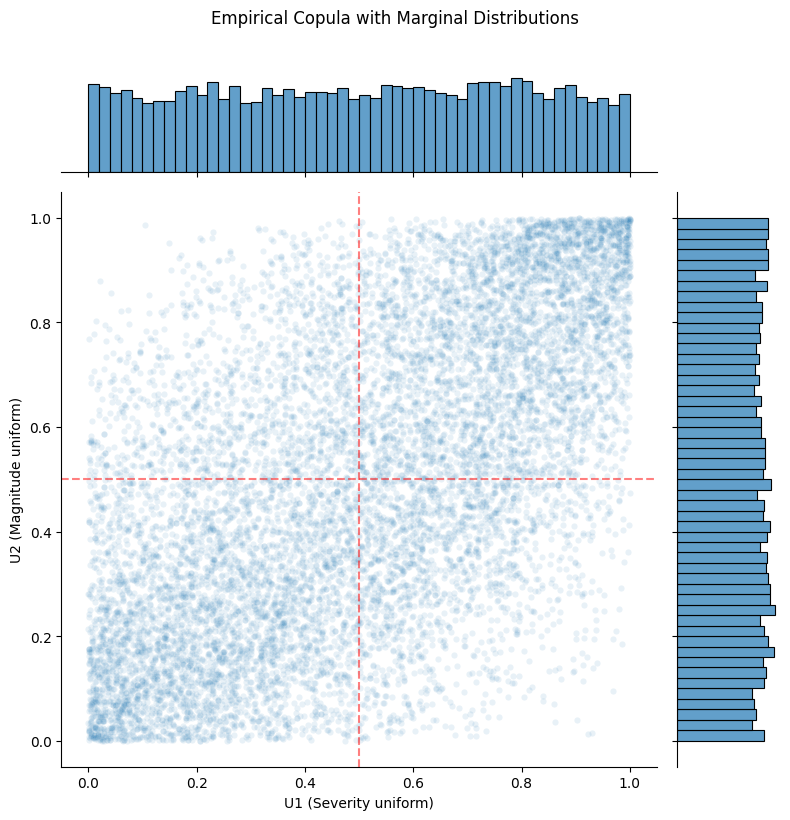

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create joint plot with marginals using seaborn
g = sns.jointplot(x=U[:, 0], y=U[:, 1], 
                 kind='scatter',
                 alpha=0.1, 
                 s=20,
                 height=8,
                 marginal_kws={'bins': 50, 'alpha': 0.7})

# Customize labels and title
g.set_axis_labels('U1 (Severity uniform)', 'U2 (Magnitude uniform)')
g.figure.suptitle('Empirical Copula with Marginal Distributions', y=1.02)

# Add reference lines for independence
g.ax_joint.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
g.ax_joint.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [49]:
from scipy.stats import multivariate_t, multivariate_normal, t, norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def select_best_copula(u1, u2, candidates=None):
   """
   Select best-fitting copula based on log-likelihood comparison.
   
   Parameters:
   -----------
   u1, u2 : array-like
       Uniform marginals [0,1]
   candidates : list of str
       Copula types to test
   
   Returns:
   --------
   tuple : (best_copula_name, best_params, results_summary)
   """
   
   if candidates is None:
       candidates = ['gaussian', 't_copula', 'clayton', 'gumbel', 'frank']
   
   results = {}
   
   # Gaussian copula
   if 'gaussian' in candidates:
       rho = np.corrcoef(norm.ppf(u1), norm.ppf(u2))[0,1]
       loglik = multivariate_normal.logpdf(
           np.column_stack([norm.ppf(u1), norm.ppf(u2)]), 
           cov=[[1, rho], [rho, 1]]
       ).sum()
       results['gaussian'] = {'params': [rho], 'loglik': loglik, 'aic': -2*loglik + 2*1}
   
   # Student's t-copula
   if 't_copula' in candidates:
       def t_loglik(params):
           rho, nu = params
           if abs(rho) >= 1 or nu <= 2: return -1e6
           try:
               t1, t2 = t.ppf(u1, df=nu), t.ppf(u2, df=nu)
               R = np.array([[1, rho], [rho, 1]])
               ll = multivariate_t.logpdf(np.column_stack([t1, t2]), df=nu, shape=R)
               return np.sum(ll[np.isfinite(ll)])
           except: return -1e6
       
       res = minimize(lambda x: -t_loglik(x), [0.5, 5], bounds=[(-0.99, 0.99), (2.1, 30)])
       results['t_copula'] = {'params': res.x, 'loglik': -res.fun, 'aic': -2*(-res.fun) + 2*2}
   
   # Clayton copula (lower tail dependence)
   if 'clayton' in candidates:
       def clayton_loglik(theta):
           if theta <= 0: return -1e6
           try:
               c = (1 + theta) * (u1 * u2)**(-1-theta) * (u1**(-theta) + u2**(-theta) - 1)**(-1/theta - 2)
               return np.sum(np.log(c[c > 0]))
           except: return -1e6
       
       res = minimize(lambda x: -clayton_loglik(x[0]), [1.0], bounds=[(0.01, 10)])
       results['clayton'] = {'params': res.x, 'loglik': -res.fun, 'aic': -2*(-res.fun) + 2*1}
   
   # Gumbel copula (upper tail dependence)
   if 'gumbel' in candidates:
       def gumbel_loglik(theta):
           if theta < 1: return -1e6
           try:
               # Gumbel copula density
               A = (-np.log(u1))**theta + (-np.log(u2))**theta
               c = np.exp(-A**(1/theta)) * A**(1/theta - 2) * ((-np.log(u1))*(-np.log(u2)))**(theta-1) * \
                   (1 + (theta-1)*A**(-1/theta)) / (u1 * u2)
               return np.sum(np.log(c[c > 0]))
           except: return -1e6
       
       res = minimize(lambda x: -gumbel_loglik(x[0]), [1.5], bounds=[(1.01, 10)])
       results['gumbel'] = {'params': res.x, 'loglik': -res.fun, 'aic': -2*(-res.fun) + 2*1}
   
   # Frank copula (symmetric dependence)
   if 'frank' in candidates:
       def frank_loglik(theta):
           if abs(theta) < 1e-6: return -1e6  # Avoid theta = 0
           try:
               # Frank copula density
               exp_theta = np.exp(-theta)
               exp_theta_u1 = np.exp(-theta * u1)
               exp_theta_u2 = np.exp(-theta * u2)
               
               numerator = -theta * (1 - exp_theta) * np.exp(-theta * (u1 + u2))
               denominator = (1 - exp_theta - (1 - exp_theta_u1) * (1 - exp_theta_u2))**2
               
               c = numerator / denominator
               return np.sum(np.log(c[c > 0]))
           except: return -1e6
       
       res = minimize(lambda x: -frank_loglik(x[0]), [2.0], bounds=[(-20, 20)])
       results['frank'] = {'params': res.x, 'loglik': -res.fun, 'aic': -2*(-res.fun) + 2*1}
   
   # Find best by AIC (lower is better)
   best_name = min(results.keys(), key=lambda k: results[k]['aic'])
   
   print("COPULA COMPARISON:")
   print("-" * 40)
   for name, result in sorted(results.items(), key=lambda x: x[1]['aic']):
       print(f"{name:12} | AIC: {result['aic']:8.1f} | LogLik: {result['loglik']:8.1f}")
   print(f"\nBest: {best_name}")
   
   return best_name, results[best_name]['params'], results

# Test copulas
best_copula, best_params, copula_summary = select_best_copula(U[:, 0], U[:, 1], candidates=['gaussian'])


COPULA COMPARISON:
----------------------------------------
gaussian     | AIC:  57785.2 | LogLik: -28891.6

Best: gaussian


## Copula family selection and fitting


GOODNESS-OF-FIT EVALUATION:
Severity uniformity p-value: 0.1145
Magnitude uniformity p-value: 0.2099
Transformed severity normality p-value: 0.0002
Transformed magnitude normality p-value: 0.0025

Best copula: gaussian with params [np.float64(0.5977423911244106)]


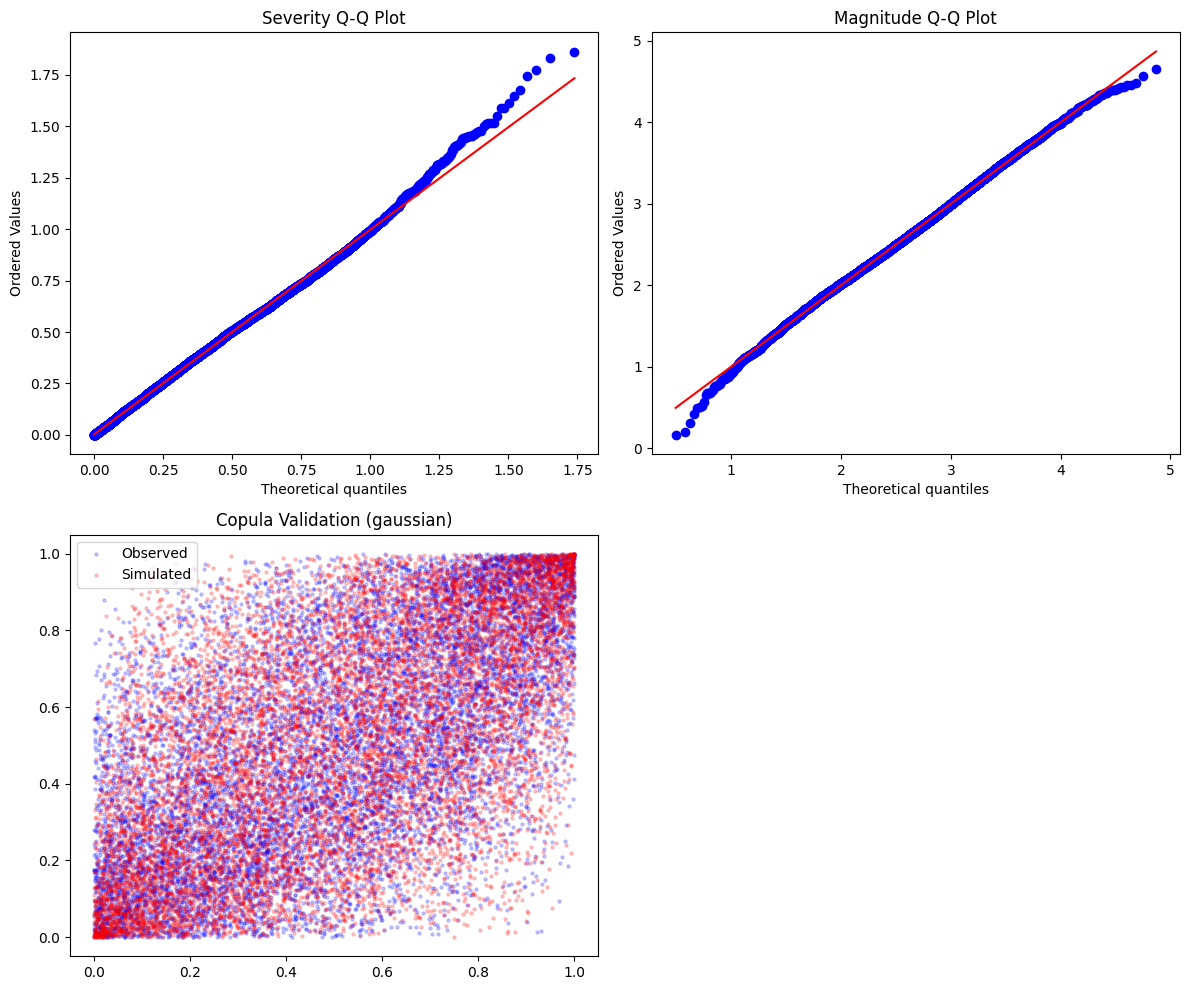

In [50]:
# 1. Visual diagnostics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Marginal Q-Q plots
from scipy import stats
import numpy as np

# Severity Q-Q plot
stats.probplot(df['severity'], dist=best_sev_dist, sparams=best_sev_params, plot=ax1)
ax1.set_title('Severity Q-Q Plot')

# Magnitude Q-Q plot  
stats.probplot(df['magnitude'], dist=best_mag_dist, sparams=best_mag_params, plot=ax2)
ax2.set_title('Magnitude Q-Q Plot')

# Copula validation: empirical vs theoretical
n_sim = U.shape[0]

# Generate from best fitted copula
if best_copula == 'gaussian':
   rho = best_params[0]
   z1, z2 = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n_sim).T
   u1_sim, u2_sim = stats.norm.cdf(z1), stats.norm.cdf(z2)
elif best_copula == 't_copula':
   rho, nu = best_params
   z1, z2 = np.random.multivariate_t([0, 0], [[1, rho], [rho, 1]], df=nu, size=n_sim).T
   u1_sim, u2_sim = stats.t.cdf(z1, df=nu), stats.t.cdf(z2, df=nu)
elif best_copula == 'clayton':
   theta = best_params[0]
   # Clayton copula simulation (simplified)
   u1_sim = np.random.uniform(0, 1, n_sim)
   v = np.random.uniform(0, 1, n_sim)
   u2_sim = (1 + u1_sim**(-theta) * (v**(-theta/(1+theta)) - 1))**(-1/theta)
elif best_copula == 'gumbel':
   theta = best_params[0]
   # Gumbel copula simulation (simplified)
   u1_sim = np.random.uniform(0, 1, n_sim)
   v = np.random.uniform(0, 1, n_sim)
   u2_sim = np.exp(-((-np.log(u1_sim))**theta + (-np.log(v))**theta)**(1/theta))
   
else:
   # Fallback to Gaussian if copula not implemented
   rho = 0.593
   z1, z2 = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n_sim).T
   u1_sim, u2_sim = stats.norm.cdf(z1), stats.norm.cdf(z2)

ax3.scatter(U[:, 0], U[:, 1], alpha=0.2, s=5, label='Observed', color='blue')
ax3.scatter(u1_sim, u2_sim, alpha=0.2, s=5, label='Simulated', color='red')
ax3.set_title(f'Copula Validation ({best_copula})')
ax3.legend()

# Empty fourth subplot for now
ax4.axis('off')

# 2. Goodness-of-fit tests
print("GOODNESS-OF-FIT EVALUATION:")
print("="*40)

# Marginal fits
print(f"Severity uniformity p-value: {sev_summary[best_sev_dist.name]['ks_pval']:.4f}")
print(f"Magnitude uniformity p-value: {mag_summary[best_mag_dist.name]['ks_pval']:.4f}")

# Copula-specific normality tests
if best_copula in ['gaussian', 't_copula']:
   if best_copula == 'gaussian':
       z_obs = np.column_stack([stats.norm.ppf(U[:, 0]), stats.norm.ppf(U[:, 1])])
   else:  # t_copula
       nu = best_params[1]
       z_obs = np.column_stack([stats.t.ppf(U[:, 0], df=nu), stats.t.ppf(U[:, 1], df=nu)])
   
   from scipy.stats import jarque_bera
   jb_stat1, jb_pval1 = jarque_bera(z_obs[:, 0])
   jb_stat2, jb_pval2 = jarque_bera(z_obs[:, 1])
   print(f"Transformed severity normality p-value: {jb_pval1:.4f}")
   print(f"Transformed magnitude normality p-value: {jb_pval2:.4f}")

print(f"\nBest copula: {best_copula} with params {best_params}")

plt.tight_layout()
plt.show()

In [55]:
def marginal_exceedance_prob(threshold, variable='severity'):
   """
   Calculate marginal exceedance probability P(X > threshold).
   
   Parameters:
   -----------
   threshold : float
       Threshold value
   variable : str
       'severity' or 'magnitude'
   
   Returns:
   --------
   float : Exceedance probability
   """
   if variable == 'severity':
       return 1 - best_sev_dist.cdf(threshold, *best_sev_params)
   elif variable == 'magnitude':
       return 1 - best_mag_dist.cdf(threshold, *best_mag_params)
   else:
       raise ValueError("variable must be 'severity' or 'magnitude'")

def joint_exceedance_prob(sev_threshold, mag_threshold):
    """
    Calculate joint exceedance probability P(Severity > x AND Magnitude > y).

    Parameters:
    -----------
    sev_threshold : float
        Severity threshold
    mag_threshold : float  
        Magnitude threshold

    Returns:
    --------
    float : Joint exceedance probability
    """
    # Get marginal exceedance probabilities (survival functions)
    u_sev = 1 - best_sev_dist.cdf(sev_threshold, *best_sev_params)
    u_mag = 1 - best_mag_dist.cdf(mag_threshold, *best_mag_params)

    rho = best_params[0]
    # Transform to standard normal
    z_sev = stats.norm.ppf(1 - u_sev)
    z_mag = stats.norm.ppf(1 - u_mag)
    # Bivariate normal survival function
    joint_survival = 1 - stats.multivariate_normal.cdf([z_sev, z_mag], 
                                                    cov=[[1, rho], [rho, 1]])

   
    return joint_survival

# Example usage
print("DROUGHT RISK CALCULATIONS:")
print("="*40)

# Individual marginal probabilities
sev_90th = best_sev_dist.ppf(0.95, *best_sev_params)
mag_90th = best_mag_dist.ppf(0.95, *best_mag_params)

# mag_90th = np.log(92.26063267232695)
# sev_90th = np.log(2.2375676656708436)

# sev_90th = np.log(2.3)
# mag_90th = np.log(90)


print(f"90th percentile severity: {np.exp(sev_90th):.2f}")
print(f"90th percentile magnitude: {np.exp(mag_90th):.2f}")
print()

sev_marg = marginal_exceedance_prob(sev_90th, 'severity')
mag_marg = marginal_exceedance_prob(mag_90th, 'magnitude')
print(f"P(Severity > {sev_90th:.2f}) = {sev_marg:.3f}")
print(f"P(Magnitude > {mag_90th:.2f}) = {mag_marg:.3f}")
print()

print(f"P(Severity > {sev_90th:.2f} AND Magnitude > {mag_90th:.2f}) = {joint_exceedance_prob(sev_90th, mag_90th):.5f}")
joint = joint_exceedance_prob(sev_90th, mag_90th)

# Compare to independence assumption
independent = marginal_exceedance_prob(sev_90th, 'severity') * marginal_exceedance_prob(mag_90th, 'magnitude')
print(f"Under independence assumption: {independent:.3f}")

DROUGHT RISK CALCULATIONS:
90th percentile severity: 2.42
90th percentile magnitude: 38.87

P(Severity > 0.88) = 0.050
P(Magnitude > 3.66) = 0.050

P(Severity > 0.88 AND Magnitude > 3.66) = 0.08456
Under independence assumption: 0.003


In [56]:
## Calculate the expected interarrival time between events
# this can be done using the start and end dates of the events in df
# however, need to be careful to only compare droughts with the same realization_id
unique_relization_ids = df['realization_id'].unique()
interarrival_lengths = []
for rid in unique_relization_ids:
    df_real = df[df['realization_id'] == rid]
    
    # loop through events (columns)
    prev_drought_end = None
    for index, row in df_real.iterrows():
        start_date = pd.to_datetime(row['start'])
        end_date = pd.to_datetime(row['end'])

        if prev_drought_end is not None:
            interarrival_time_days = (start_date - prev_drought_end).days 

            interarrival_lengths.append(interarrival_time_days)
            
        prev_drought_end = end_date

interarrival_lengths = np.array(interarrival_lengths)

expected_interarrival_days = np.mean(interarrival_lengths) / 365.25  # convert to years

print(f"\nExpected interarrival time between droughts: {expected_interarrival_days:.2f} years")


Expected interarrival time between droughts: 4.14 years


In [53]:
print(f"\nExpected interarrival time between droughts: {expected_interarrival_days:.2f} years")


Expected interarrival time between droughts: 4.14 years


In [54]:
## Calculate return period as:
# E(L) / P(Severity > sev_90th AND Magnitude > mag_90th)

T = expected_interarrival_days/(sev_marg - mag_marg + joint)
T


np.float64(27.417447771302086)

In [42]:
expected_interarrival_days

np.float64(4.135422090787919)

In [44]:
sev_marg - mag_marg + joint

np.float64(0.07538962931248465)